In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ishamaryam07/ibm-hr-analytics-employee-attrition-and-performance/WA_Fn-UseC_-HR-Employee-Attrition.csv


**Applying EDA**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/kaggle/input/datasets/ishamaryam07/ibm-hr-analytics-employee-attrition-and-performance/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [4]:
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
print("Missing Values:\n", df.isnull().sum().sum())
print("\nAttrition Distribution:\n", df['Attrition'].value_counts())
print("\nAttrition Rate:", round(df['Attrition'].value_counts(normalize=True)['Yes']*100, 2), "%")

Missing Values:
 0

Attrition Distribution:
 Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12 %


In [6]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print("Attrition encoded: ")
print(df['Attrition'].value_counts())

Attrition encoded: 
Attrition
0    1233
1     237
Name: count, dtype: int64


In [7]:
df.drop(['EmployeeCount','Over18','StandardHours'], axis=1, inplace=True)
print("Remaining columns: ", df.shape[1])

Remaining columns:  32


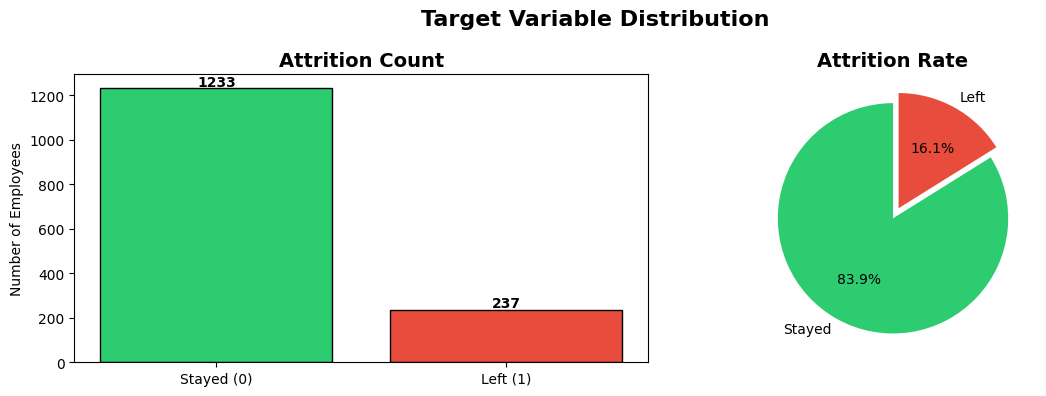

Attrition Rate: 16.12%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#count plot
axes[0].bar(['Stayed (0)', 'Left (1)'], 
            df['Attrition'].value_counts().values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Attrition Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Employees')
for i, v in enumerate(df['Attrition'].value_counts().values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(df['Attrition'].value_counts().values,
            labels=['Stayed', 'Left'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90,
            explode=(0, 0.1))
axes[1].set_title('Attrition Rate', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Attrition Rate: {df['Attrition'].mean()*100:.2f}%")

Attrition by Departement

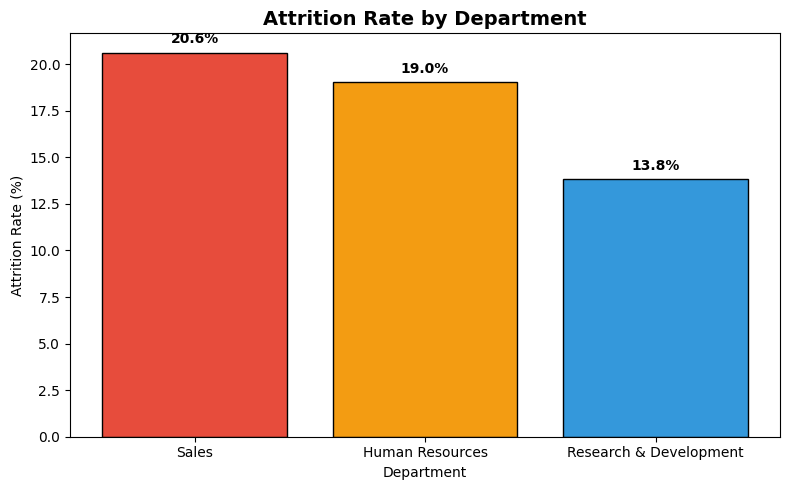

In [9]:
dept_attrition = df.groupby('Department')['Attrition'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(dept_attrition.index, dept_attrition.values,
               color=['#e74c3c', '#f39c12', '#3498db'], edgecolor='black')
plt.title('Attrition Rate by Department', fontsize=14, fontweight='bold')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Department')

for bar, val in zip(bars, dept_attrition.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Attrition y job role

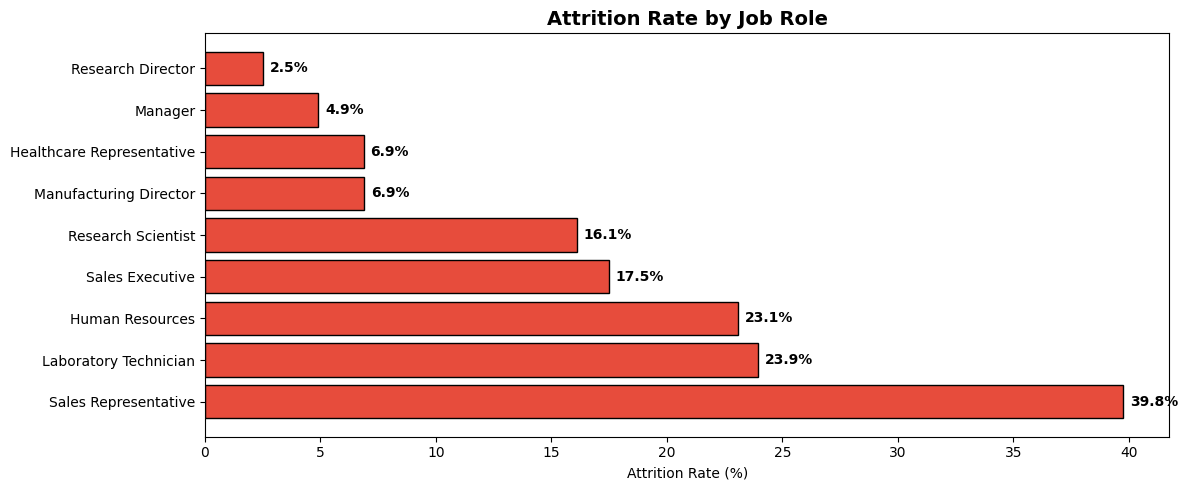

In [10]:
role_attrition = df.groupby('JobRole')['Attrition'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 5))
bars = plt.barh(role_attrition.index, role_attrition.values,
                color='#e74c3c', edgecolor='black')
plt.title('Attrition Rate by Job Role', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Rate (%)')

for bar, val in zip(bars, role_attrition.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

Attrition by OverTime

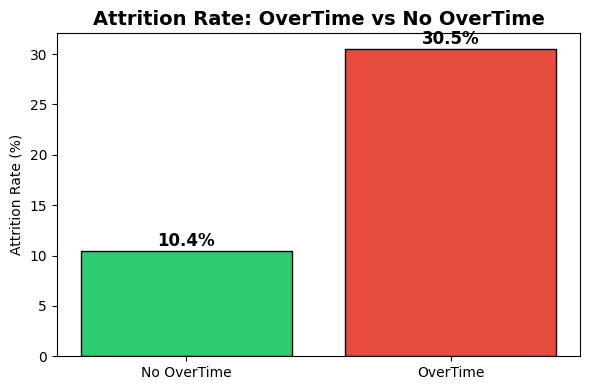

In [11]:
overtime_attrition = df.groupby('OverTime')['Attrition'].mean() * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(['No OverTime', 'OverTime'], overtime_attrition.values,
               color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Attrition Rate: OverTime vs No OverTime', fontsize=14, fontweight='bold')
plt.ylabel('Attrition Rate (%)')

for bar, val in zip(bars, overtime_attrition.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

Attrition by age group

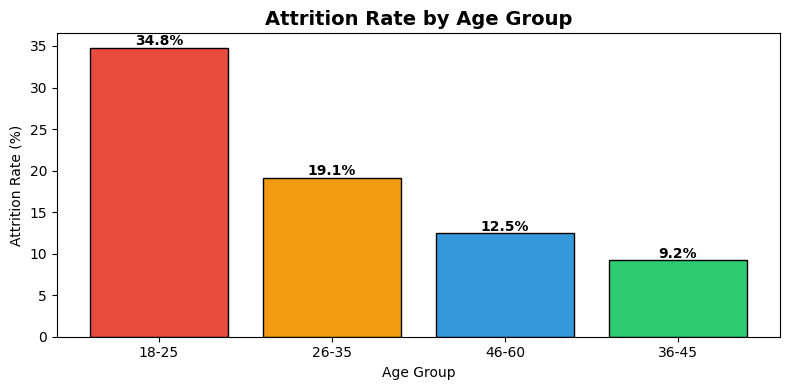

In [12]:
# Creating age bins
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 60],
                         labels=['18-25', '26-35', '36-45', '46-60'])

age_attrition = df.groupby('AgeGroup', observed=True)['Attrition'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 4))
bars = plt.bar(age_attrition.index.astype(str), age_attrition.values,
               color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'], edgecolor='black')
plt.title('Attrition Rate by Age Group', fontsize=14, fontweight='bold')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Age Group')

for bar, val in zip(bars, age_attrition.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
df.drop('AgeGroup', axis=1, inplace=True)

Attribution by Salary(monthly)

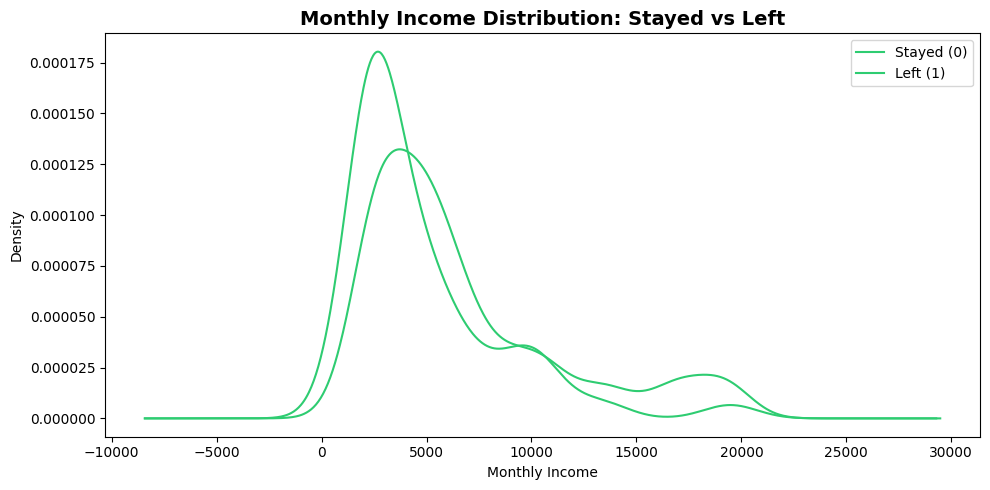

Avg Income - Stayed: 6832.74
Avg Income - Left: 4787.09


In [13]:
plt.figure(figsize=(10, 5))
df.groupby('Attrition')['MonthlyIncome'].plot(kind='kde',
                                               legend=True,
                                               color=['#2ecc71', '#e74c3c'])
plt.title('Monthly Income Distribution: Stayed vs Left', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Income')
plt.legend(['Stayed (0)', 'Left (1)'])
plt.tight_layout()
plt.show()

print("Avg Income - Stayed:", round(df[df['Attrition']==0]['MonthlyIncome'].mean(), 2))
print("Avg Income - Left:", round(df[df['Attrition']==1]['MonthlyIncome'].mean(), 2))

Correlation Heatmap

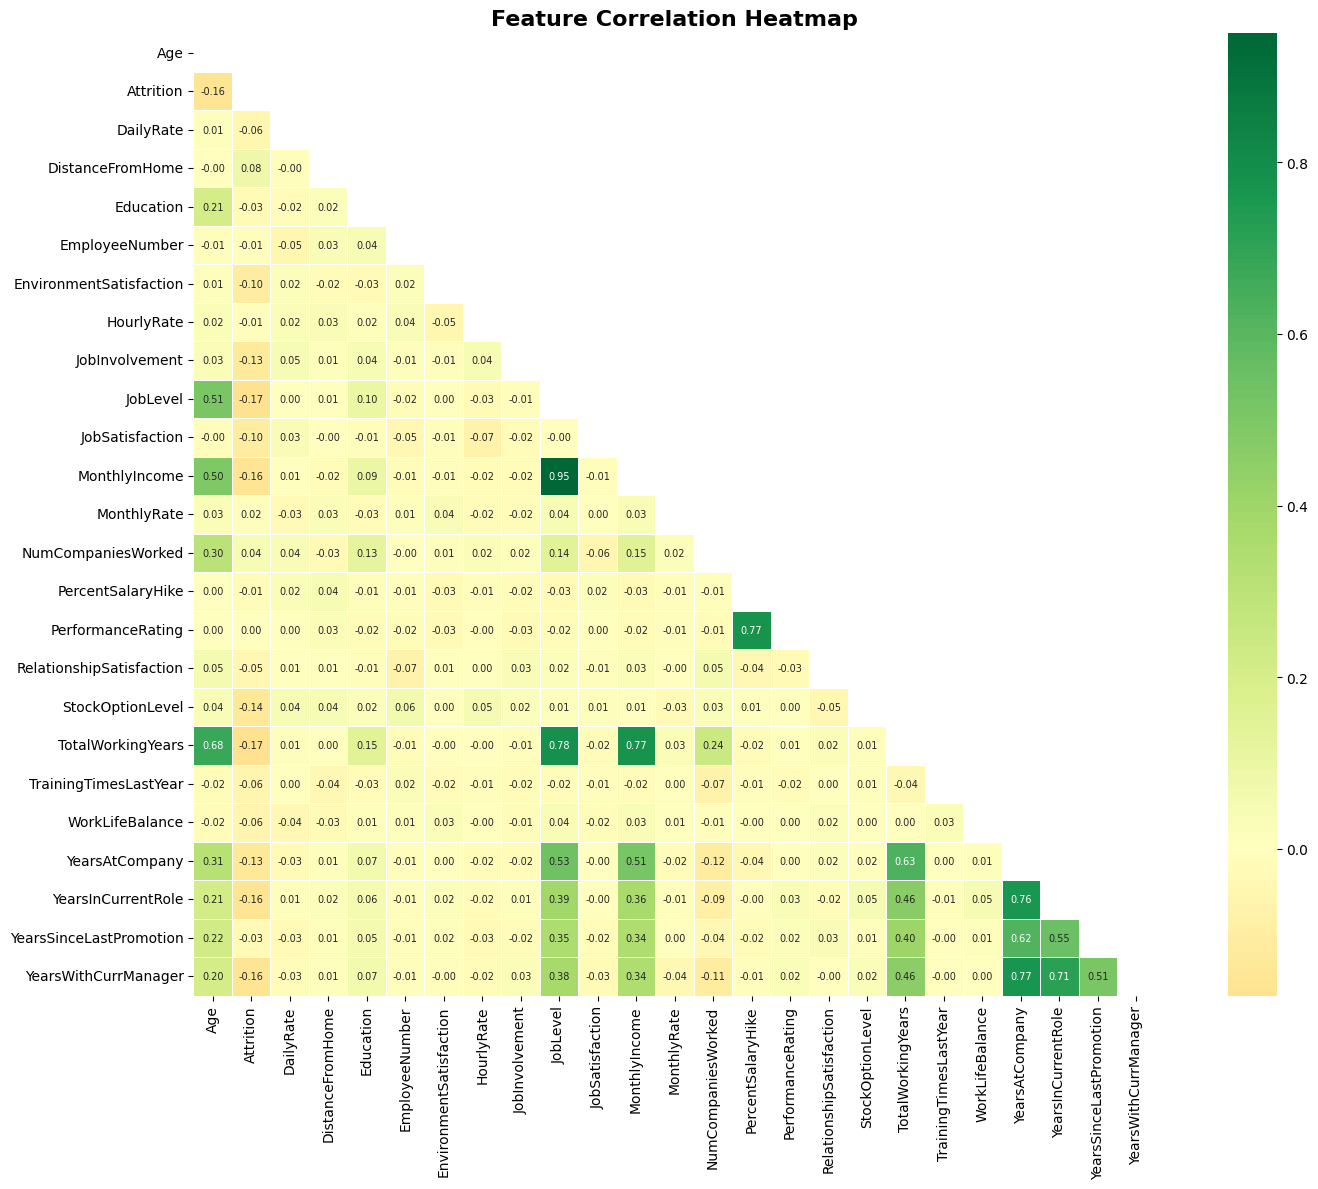

In [14]:
plt.figure(figsize=(16, 12))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 7})

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

 EDA Summary 

In [15]:
print("=" * 55)
print("        EDA KEY FINDINGS SUMMARY")
print("=" * 55)
print(f"Total Employees       : {len(df)}")
print(f"Attrition Rate        : {df['Attrition'].mean()*100:.1f}%")
print(f"Highest Risk Dept     : Sales")
print(f"Highest Risk Role     : Sales Representative (~40%)")
print(f"OverTime Impact       : 3x higher attrition")
print(f"Most At-Risk Age      : 18-25 years")
print(f"Avg Income (Left)     : ${df[df['Attrition']==1]['MonthlyIncome'].mean():,.0f}")
print(f"Avg Income (Stayed)   : ${df[df['Attrition']==0]['MonthlyIncome'].mean():,.0f}")
print("=" * 55)
print("Next Step → Feature Engineering")

        EDA KEY FINDINGS SUMMARY
Total Employees       : 1470
Attrition Rate        : 16.1%
Highest Risk Dept     : Sales
Highest Risk Role     : Sales Representative (~40%)
OverTime Impact       : 3x higher attrition
Most At-Risk Age      : 18-25 years
Avg Income (Left)     : $4,787
Avg Income (Stayed)   : $6,833
Next Step → Feature Engineering


**Feature Engineering**

In [16]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:", categorical_cols)
print("\nTotal categorical:", len(categorical_cols))

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

Categorical Columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Total categorical: 7
BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Department: ['Sales' 'Research & Development' 'Human Resources']
EducationField: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Gender: ['Female' 'Male']
JobRole: ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
MaritalStatus: ['Single' 'Married' 'Divorced']
OverTime: ['Yes' 'No']


In [17]:
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

print("OverTime encoded:", df['OverTime'].unique())
print("Gender encoded:", df['Gender'].unique())

OverTime encoded: [1 0]
Gender encoded: [0 1]


In [18]:
df['Satisfaction_Score'] = (
    df['JobSatisfaction'] +
    df['EnvironmentSatisfaction'] +
    df['RelationshipSatisfaction'] +
    df['WorkLifeBalance']
) / 4

print("Satisfaction_Score stats:")
print(df['Satisfaction_Score'].describe())
print("\nAvg score - Stayed:", round(df[df['Attrition']==0]['Satisfaction_Score'].mean(), 3))
print("Avg score - Left  :", round(df[df['Attrition']==1]['Satisfaction_Score'].mean(), 3))

Satisfaction_Score stats:
count    1470.000000
mean        2.730952
std         0.505815
min         1.000000
25%         2.500000
50%         2.750000
75%         3.000000
max         4.000000
Name: Satisfaction_Score, dtype: float64

Avg score - Stayed: 2.766
Avg score - Left  : 2.547


Promotion_Lag stats:
count    1470.000000
mean        4.820408
std         4.847756
min         0.000000
25%         1.000000
50%         4.000000
75%         7.000000
max        36.000000
Name: Promotion_Lag, dtype: float64

Avg Promotion Lag - Stayed: 5.13
Avg Promotion Lag - Left  : 3.19


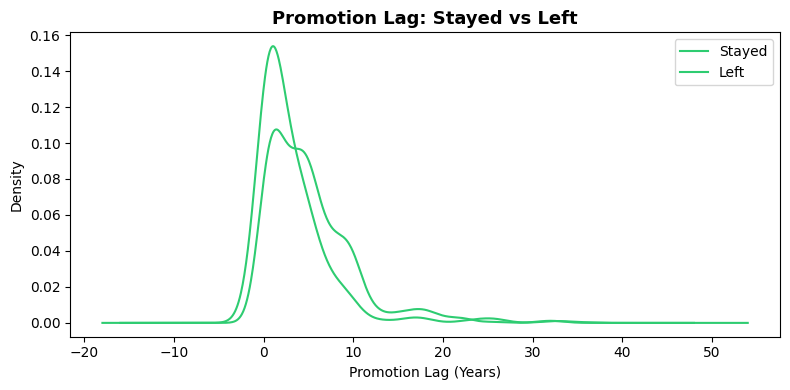

In [19]:
df['Promotion_Lag'] = df['YearsAtCompany'] - df['YearsSinceLastPromotion']

print("Promotion_Lag stats:")
print(df['Promotion_Lag'].describe())
print("\nAvg Promotion Lag - Stayed:", round(df[df['Attrition']==0]['Promotion_Lag'].mean(), 2))
print("Avg Promotion Lag - Left  :", round(df[df['Attrition']==1]['Promotion_Lag'].mean(), 2))

# Visualize it
plt.figure(figsize=(8, 4))
df.groupby('Attrition')['Promotion_Lag'].plot(kind='kde', legend=True,
                                               color=['#2ecc71','#e74c3c'])
plt.title('Promotion Lag: Stayed vs Left', fontsize=13, fontweight='bold')
plt.xlabel('Promotion Lag (Years)')
plt.legend(['Stayed', 'Left'])
plt.tight_layout()
plt.show()

In [20]:
df['Tenure_Per_Company'] = df['TotalWorkingYears'] / (df['NumCompaniesWorked'] + 1)

print("Tenure_Per_Company stats:")
print(df['Tenure_Per_Company'].describe())
print("\nAvg Tenure/Company - Stayed:", round(df[df['Attrition']==0]['Tenure_Per_Company'].mean(), 2))
print("Avg Tenure/Company - Left  :", round(df[df['Attrition']==1]['Tenure_Per_Company'].mean(), 2))

Tenure_Per_Company stats:
count    1470.000000
mean        4.193478
std         4.035504
min         0.000000
25%         1.600000
50%         3.000000
75%         5.000000
max        38.000000
Name: Tenure_Per_Company, dtype: float64

Avg Tenure/Company - Stayed: 4.46
Avg Tenure/Company - Left  : 2.81


In [21]:
df['WorkLife_Stress_Index'] = df['OverTime'] * (5 - df['WorkLifeBalance'])

print("WorkLife_Stress_Index distribution:")
print(df['WorkLife_Stress_Index'].value_counts().sort_index())
print("\nAvg Stress - Stayed:", round(df[df['Attrition']==0]['WorkLife_Stress_Index'].mean(), 3))
print("Avg Stress - Left  :", round(df[df['Attrition']==1]['WorkLife_Stress_Index'].mean(), 3))

WorkLife_Stress_Index distribution:
WorkLife_Stress_Index
0    1054
1      36
2     254
3     104
4      22
Name: count, dtype: int64

Avg Stress - Stayed: 0.527
Avg Stress - Left  : 1.241


In [22]:
df['Salary_Growth_Rate'] = df['PercentSalaryHike'] / (df['YearsAtCompany'] + 1)

print("Salary_Growth_Rate stats:")
print(df['Salary_Growth_Rate'].describe())
print("\nAvg Growth Rate - Stayed:", round(df[df['Attrition']==0]['Salary_Growth_Rate'].mean(), 3))
print("Avg Growth Rate - Left  :", round(df[df['Attrition']==1]['Salary_Growth_Rate'].mean(), 3))

Salary_Growth_Rate stats:
count    1470.000000
mean        3.368343
std         3.180950
min         0.292683
25%         1.400000
50%         2.250000
75%         4.125000
max        24.000000
Name: Salary_Growth_Rate, dtype: float64

Avg Growth Rate - Stayed: 3.098
Avg Growth Rate - Left  : 4.777


In [23]:
df['Experience_Age_Ratio'] = df['TotalWorkingYears'] / df['Age']

print("Experience_Age_Ratio stats:")
print(df['Experience_Age_Ratio'].describe())
print("\nAvg Ratio - Stayed:", round(df[df['Attrition']==0]['Experience_Age_Ratio'].mean(), 3))
print("Avg Ratio - Left  :", round(df[df['Attrition']==1]['Experience_Age_Ratio'].mean(), 3))

Experience_Age_Ratio stats:
count    1470.000000
mean        0.288007
std         0.153429
min         0.000000
25%         0.181818
50%         0.264706
75%         0.400000
max         0.689655
Name: Experience_Age_Ratio, dtype: float64

Avg Ratio - Stayed: 0.3
Avg Ratio - Left  : 0.224


In [24]:
df['Manager_Relationship_Risk'] = (
    (5 - df['RelationshipSatisfaction']) *
    (1 / (df['YearsWithCurrManager'] + 1))
)

print("Manager_Relationship_Risk stats:")
print(df['Manager_Relationship_Risk'].describe())
print("\nAvg Risk - Stayed:", round(df[df['Attrition']==0]['Manager_Relationship_Risk'].mean(), 3))
print("Avg Risk - Left  :", round(df[df['Attrition']==1]['Manager_Relationship_Risk'].mean(), 3))

Manager_Relationship_Risk stats:
count    1470.000000
mean        0.832503
std         0.892863
min         0.055556
25%         0.250000
50%         0.500000
75%         1.000000
max         4.000000
Name: Manager_Relationship_Risk, dtype: float64

Avg Risk - Stayed: 0.752
Avg Risk - Left  : 1.253


In [25]:
new_features = [
    'Satisfaction_Score',
    'Promotion_Lag',
    'Tenure_Per_Company',
    'WorkLife_Stress_Index',
    'Salary_Growth_Rate',
    'Experience_Age_Ratio',
    'Manager_Relationship_Risk'
]

print("=" * 50)
print("   ALL ENGINEERED FEATURES — NULL CHECK")
print("=" * 50)
for f in new_features:
    nulls = df[f].isnull().sum()
    status = "✅" if nulls == 0 else "❌"
    print(f"{status} {f}: {nulls} nulls | range [{df[f].min():.2f}, {df[f].max():.2f}]")

print(f"\nDataset shape after FE: {df.shape}")

   ALL ENGINEERED FEATURES — NULL CHECK
✅ Satisfaction_Score: 0 nulls | range [1.00, 4.00]
✅ Promotion_Lag: 0 nulls | range [0.00, 36.00]
✅ Tenure_Per_Company: 0 nulls | range [0.00, 38.00]
✅ WorkLife_Stress_Index: 0 nulls | range [0.00, 4.00]
✅ Salary_Growth_Rate: 0 nulls | range [0.29, 24.00]
✅ Experience_Age_Ratio: 0 nulls | range [0.00, 0.69]
✅ Manager_Relationship_Risk: 0 nulls | range [0.06, 4.00]

Dataset shape after FE: (1470, 39)


In [26]:
from sklearn.preprocessing import LabelEncoder
ohe_cols = ['BusinessTravel', 'Department', 'EducationField', 
            'JobRole', 'MaritalStatus']

df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print("\nAll columns now numeric:", 
      df.select_dtypes(include=['object']).shape[1] == 0)
print("\nFinal columns:", df.columns.tolist())

Shape after encoding: (1470, 53)

All columns now numeric: True

Final columns: ['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Satisfaction_Score', 'Promotion_Lag', 'Tenure_Per_Company', 'WorkLife_Stress_Index', 'Salary_Growth_Rate', 'Experience_Age_Ratio', 'Manager_Relationship_Risk', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical D

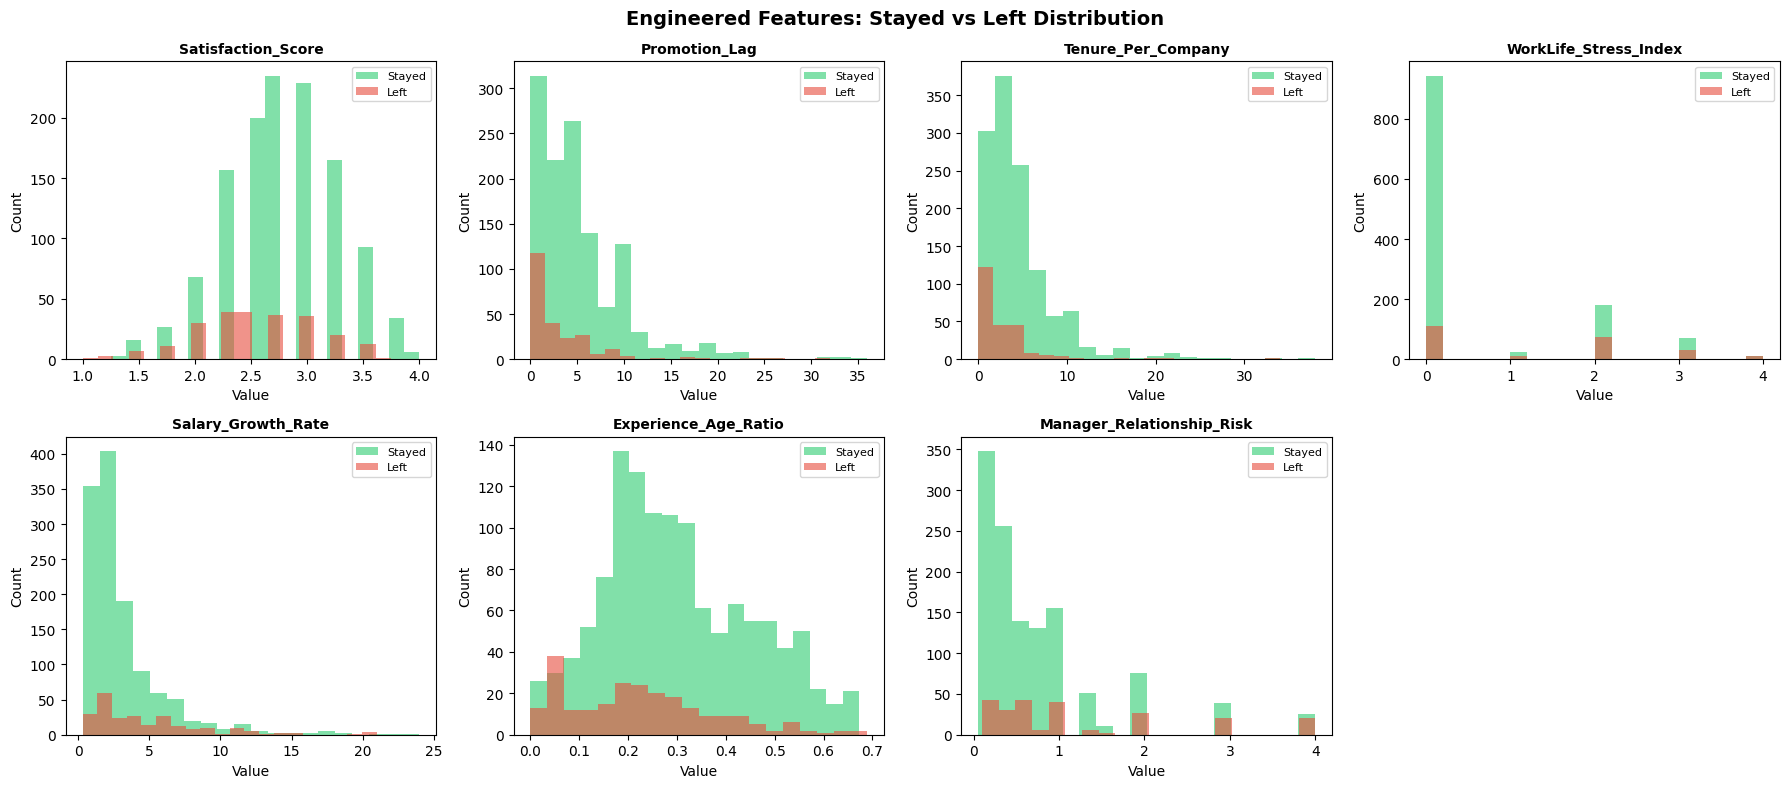

In [27]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(new_features):
    stayed = df[df['Attrition']==0][feature]
    left = df[df['Attrition']==1][feature]
    
    axes[i].hist(stayed, bins=20, alpha=0.6, color='#2ecc71', label='Stayed')
    axes[i].hist(left, bins=20, alpha=0.6, color='#e74c3c', label='Left')
    axes[i].set_title(feature, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)

plt.suptitle('Engineered Features: Stayed vs Left Distribution', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
print("=" * 50)
print("   PRE-MODELING CHECKLIST")
print("=" * 50)
print(f"✅ Dataset shape     : {df.shape}")
print(f"✅ Target (Attrition): {df['Attrition'].unique()}")
print(f"✅ Attrition rate    : {df['Attrition'].mean()*100:.1f}%")
print(f"✅ Any nulls         : {df.isnull().sum().sum()}")
print(f"✅ Object columns    : {df.select_dtypes(include='object').columns.tolist()}")
print(f"✅ Total features    : {df.shape[1] - 1}")
print("=" * 50)


   PRE-MODELING CHECKLIST
✅ Dataset shape     : (1470, 53)
✅ Target (Attrition): [1 0]
✅ Attrition rate    : 16.1%
✅ Any nulls         : 0
✅ Object columns    : []
✅ Total features    : 52
